# Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp

In [2]:

# ============================================================
# 0. LOAD XLSX + remove first column
# ============================================================
raw = pd.read_excel("../data/Track2_QML/xlsx/train.xlsx").values
dataset_train = raw[:, 1:]


# ============================================================
# 1. PCA 2D
# ============================================================
def compute_pca(data):
    pca = PCA(n_components=2)
    data2 = pca.fit_transform(data)
    return data2, pca


# ============================================================
# 2. Windows t1–t3 → t4–t6
# ============================================================
def make_windows(data2):
    X, Y = [], []
    T = len(data2)
    for t in range(T - 6):
        X.append(data2[t:t+3])
        Y.append(data2[t+3:t+6])
    return np.array(X), np.array(Y)


# ============================================================
# 3. Dataset
# ============================================================
class TimeDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


# ============================================================
# 4. NEW PARAMETRIC CIRCUIT — exactly as you want
# ============================================================
def make_feature_circuit(n=6, reps=4):
    qc = QuantumCircuit(n)

    # ---- 1) ENCODAGE DATA (UNE SEULE FOIS) ----
    data_params = []
    for q in range(n):
        p = Parameter(f"data_{q}")
        qc.ry(p, q)
        data_params.append(p)

    # ---- 2) BLOCS THETA + CASCADE CZ ----
    theta_params = []

    for r in range(reps):
        row = []
        # couche RY(theta)
        for q in range(n):
            t = Parameter(f"theta_{r}_{q}")
            qc.ry(t, q)
            row.append(t)
        theta_params.append(row)

        # cascade CZ
        for q in range(n - 1):
            qc.cz(q, q + 1)

    return qc, data_params, theta_params


# ============================================================
# 5. Quantum layer <Z_i>
# ============================================================
class QiskitObsLayer(nn.Module):
    def __init__(self, n=6, reps=4):
        super().__init__()
        self.n = n
        self.reps = reps

        self.template, self.data_params, self.theta_params = make_feature_circuit(n, reps)
        self.theta = nn.Parameter(0.01 * torch.randn(reps, n))

        self.obs = [
            SparsePauliOp.from_list([("I"*i + "Z" + "I"*(n-i-1), 1.0)])
            for i in range(n)
        ]

    def forward(self, x):
        B = x.shape[0]
        out = []

        for b in range(B):
            # x[b] = (3,2) → flatten to 6 angles, encoded ONCE
            angles = x[b].reshape(6).tolist()

            assign = {}

            # data encoding
            for q in range(self.n):
                assign[self.data_params[q]] = float(angles[q])

            # theta blocks
            for r in range(self.reps):
                for q in range(self.n):
                    assign[self.theta_params[r][q]] = float(self.theta[r, q].detach())

            circ = self.template.assign_parameters(assign)
            state = Statevector.from_instruction(circ)

            vals = []
            for obs in self.obs:
                vals.append(float(state.expectation_value(obs).real))

            out.append(vals)

        return torch.tensor(out, dtype=torch.float32)


# ============================================================
# 6. Full model
# ============================================================
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.q = QiskitObsLayer()
        self.fc = nn.Linear(6, 6)
    def forward(self, x):
        q_out = self.q(x)
        y = self.fc(q_out)
        return y.view(-1, 3, 2)


# ============================================================
# 7. Training
# ============================================================
def train_model(dataset_train, epochs=20, bs=8):
    data2, pca = compute_pca(dataset_train)
    X, Y = make_windows(data2)

    loader = DataLoader(TimeDataset(X, Y), batch_size=bs, shuffle=True)

    model = Model()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        tot = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item()
        print("epoch", epoch, "loss", tot/len(loader))

    return model, pca


# ============================================================
# 8. Autoregressive prediction
# ============================================================
def generate_next(model, pca, dataset_train, steps=2):
    last3 = dataset_train[-3:]
    seq = pca.transform(last3)

    gen = []

    for _ in range(steps):
        inp = torch.tensor(seq[-3:], dtype=torch.float32).unsqueeze(0)
        out = model(inp)[0].detach().numpy()
        gen.append(out)
        seq = np.vstack([seq, out])

    gen = np.vstack(gen)
    return pca.inverse_transform(gen)



In [3]:
# ============================================================
# TRAIN + GENERATE
# ============================================================
model, pca = train_model(dataset_train)
future_points = generate_next(model, pca, dataset_train, steps=2)


# ============================================================
# 9. Build final dataset with Tenor/Maturity grid + Dates
# ============================================================
tenors = [1,2,3,4,5,6,7,8,9,10,15,20,25,30]
maturities = [0.0833333333333333, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

columns = []
for mat in maturities:
    for ten in tenors:
        columns.append(f"Tenor : {ten}; Maturity : {mat}")

dates = [
    "24/12/2051",
    "26/12/2051",
    "27/12/2051",
    "29/12/2051",
    "30/12/2051",
    "01/01/2052"
]

N = len(dates)
final_data = future_points[:N, :len(columns)]

df_final = pd.DataFrame(final_data, columns=columns)
df_final.insert(0, "Date", dates)

print(df_final)
df_final.to_excel("final_dataset.xlsx", index=False)
df_final.to_csv("final_dataset.csv", index=False)


epoch 0 loss 0.39737233739407335
epoch 1 loss 0.14610677078121997
epoch 2 loss 0.06932043278070747
epoch 3 loss 0.04942706489904982
epoch 4 loss 0.04449408241837728
epoch 5 loss 0.04341283153559341
epoch 6 loss 0.04326237475530046
epoch 7 loss 0.04320645556769899
epoch 8 loss 0.043176229707286004
epoch 9 loss 0.043197039759061376
epoch 10 loss 0.04324672184884548
epoch 11 loss 0.04316084865541732
epoch 12 loss 0.0431336876859919
epoch 13 loss 0.043211085721850395
epoch 14 loss 0.043092734989572744
epoch 15 loss 0.0430689451635861
epoch 16 loss 0.043205235733604824
epoch 17 loss 0.043114568946547194
epoch 18 loss 0.043033872043988744
epoch 19 loss 0.04299816431202849
         Date  Tenor : 1; Maturity : 0.0833333333333333  \
0  24/12/2051                                  0.030357   
1  26/12/2051                                  0.030680   
2  27/12/2051                                  0.029943   
3  29/12/2051                                  0.029900   
4  30/12/2051                 

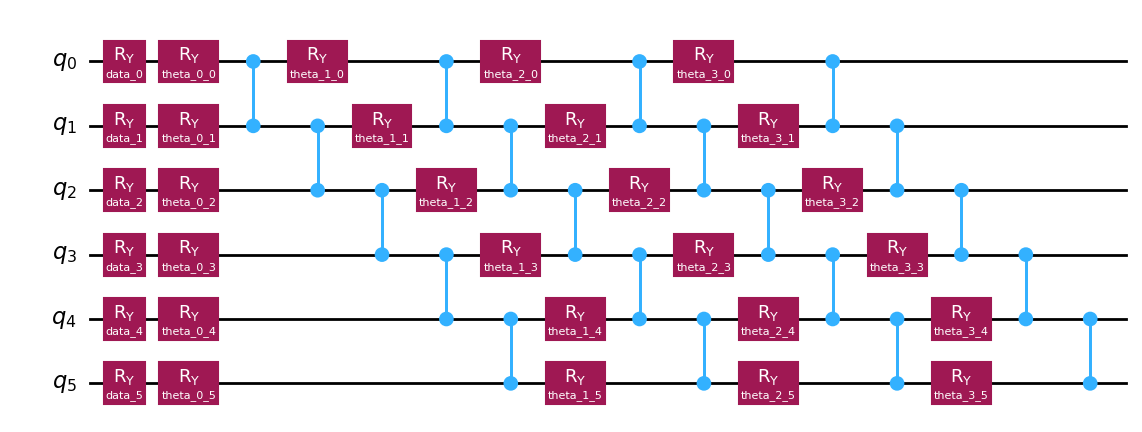

In [4]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# Create the circuit
qc, data_params, theta_params = make_feature_circuit(n=6, reps=4)

# Draw the circuit using matplotlib
qc.draw(output='mpl', style='iqp', fold=-1)


# Optionally, save the figure
# fig.savefig('quantum_circuit.png', dpi=300, bbox_inches='tight')

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager
from qiskit.circuit.library import XGate
from qiskit_ibm_runtime.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis, 
    PadDynamicalDecoupling, 
    DynamicCircuitInstructionDurations
)

# ============================================================
# 1. Initialize IBM Quantum Service
# ============================================================
service = QiskitRuntimeService()

# Get available backends
least_busy_backend = service.least_busy(simulator=False, operational=True)
# Or pick a specific backend like Quebec
# pick_backend = service.backend("ibm_quebec")
pick_backend = service.backend("ibm_quebec")

print(f"Least busy backend: {least_busy_backend.name}")
print(f"Selected backend: {pick_backend.name}")

# Choose which backend to use
backend = least_busy_backend  # or pick_backend

# ============================================================
# 2. Create circuit with measurements
# ============================================================
def make_measurable_circuit(n=6, reps=4, data_angles=None, theta_angles=None):
    """Create a quantum circuit with measurements for hardware execution"""
    qc = QuantumCircuit(n, n)  # Add classical bits for measurement
    data_params, theta_params = [], []

    for r in range(reps):
        row_d = []
        for q in range(n):
            if data_angles is not None:
                qc.ry(data_angles[r][q], q)
            else:
                p = Parameter(f"data_{r}_{q}")
                qc.ry(p, q)
                row_d.append(p)
        if data_angles is None:
            data_params.append(row_d)

        for q in range(n - 1):
            qc.cz(q, q + 1)

        row_t = []
        for q in range(n):
            if theta_angles is not None:
                qc.ry(theta_angles[r][q], q)
            else:
                t = Parameter(f"theta_{r}_{q}")
                qc.ry(t, q)
                row_t.append(t)
        if theta_angles is None:
            theta_params.append(row_t)

    # Add measurements
    qc.measure(range(n), range(n))
    
    return qc, data_params, theta_params


# ============================================================
# 3. Setup transpilation with dynamical decoupling
# ============================================================
target = backend.target
durations = DynamicCircuitInstructionDurations.from_backend(backend=backend)

optimized_pm = generate_preset_pass_manager(target=target, optimization_level=3)

# Add dynamical decoupling
dd_rep = 8
dd_sequence = [XGate()] * dd_rep

optimized_pm.scheduling = PassManager([
    ALAPScheduleAnalysis(durations=durations),
    PadDynamicalDecoupling(
        durations=durations,
        dd_sequences=dd_sequence,
        pulse_alignment=16
    )
])


Least busy backend: ibm_quebec
Selected backend: ibm_quebec


In [ ]:
# ============================================================
# 4. Prepare and transpile circuits
# ============================================================
# Example: Get parameter values from trained model
sample_input = torch.tensor([[0.1, 0.2, 0.1, 0.2, 0.1, 0.2]], dtype=torch.float32)
angles = sample_input[0].reshape(6).tolist()

# Assign parameters
qc_template, data_params, theta_params = make_feature_circuit(n=6, reps=4)

assign = {}

# Data encoding parameters (flat list of 6 parameters)
for q in range(6):
    assign[data_params[q]] = float(angles[q])

# Theta parameters (2D list: reps x qubits)
for r in range(4):
    for q in range(6):
        assign[theta_params[r][q]] = float(model.q.theta[r, q].detach())

# Create bound circuit with measurements
qc_bound = qc_template.assign_parameters(assign)
qc_measured = qc_bound.copy()
qc_measured.measure_all()

# Transpile multiple times for better results
NUM_TRIALS = 10
transpiled_circuits = []
for i in range(NUM_TRIALS):
    transpiled_circuits.append(optimized_pm.run(qc_measured))

depths = [circuit.depth() for circuit in transpiled_circuits]
print(f"Circuit depths: {depths}")
print(f"Average depth: {sum(depths) / len(depths):.2f}")


# ============================================================
# 5. Hardware-based Quantum layer <Z_i>
# ============================================================
class QiskitHardwareLayer(nn.Module):
    def __init__(self, backend, n=6, reps=4, shots=1024):
        super().__init__()
        self.n = n
        self.reps = reps
        self.shots = shots
        self.backend = backend
        
        self.template, self.data_params, self.theta_params = make_feature_circuit(n, reps)
        self.theta = nn.Parameter(0.01 * torch.randn(reps, n))
        
        # Setup transpilation
        target = backend.target
        durations = DynamicCircuitInstructionDurations.from_backend(backend=backend)
        self.pm = generate_preset_pass_manager(target=target, optimization_level=3)
        
        # Add dynamical decoupling
        dd_sequence = [XGate()] * 8
        self.pm.scheduling = PassManager([
            ALAPScheduleAnalysis(durations=durations),
            PadDynamicalDecoupling(
                durations=durations,
                dd_sequences=dd_sequence,
                pulse_alignment=16
            )
        ])

    def forward(self, x):
        B = x.shape[0]
        out = []
        
        sampler = Sampler(self.backend)

        for b in range(B):
            angles = x[b].reshape(6).tolist()
            
            assign = {}
            
            # Data encoding parameters
            for q in range(self.n):
                assign[self.data_params[q]] = float(angles[q])
            
            # Theta parameters
            for r in range(self.reps):
                for q in range(self.n):
                    assign[self.theta_params[r][q]] = float(self.theta[r, q].detach())
            
            # Create circuits to measure each qubit (Z expectation)
            circuits = []
            for q in range(self.n):
                circ = self.template.assign_parameters(assign)
                circ.measure_all()
                transpiled = self.pm.run(circ)
                circuits.append(transpiled)
            
            # Submit job
            job = sampler.run(circuits, shots=self.shots)
            result = job.result()
            
            # Compute expectation values from measurement counts
            vals = []
            for i, pub_result in enumerate(result):
                counts = pub_result.data.meas.get_counts()
                
                # Calculate <Z_i> from measurement statistics
                expectation = 0.0
                total_shots = sum(counts.values())
                
                for bitstring, count in counts.items():
                    # Convert bitstring to list (reversed for qiskit convention)
                    bits = [int(b) for b in bitstring[::-1]]
                    # Z eigenvalue: |0⟩ → +1, |1⟩ → -1
                    z_value = 1 - 2 * bits[i]
                    expectation += z_value * count / total_shots
                
                vals.append(expectation)
            
            out.append(vals)
            
            print(f"Batch {b+1}/{B} complete")

        return torch.tensor(out, dtype=torch.float32)


# ============================================================
# 6. Modified Model for hardware
# ============================================================
class HardwareModel(nn.Module):
    def __init__(self, backend):
        super().__init__()
        self.q = QiskitHardwareLayer(backend)
        self.fc = nn.Linear(6, 6)
    
    def forward(self, x):
        q_out = self.q(x)
        y = self.fc(q_out)
        return y.view(-1, 3, 2)


# ============================================================
# 7. Training on hardware (1 epoch)
# ============================================================
def train_model_on_hardware(dataset_train, backend, epochs=1, bs=2):
    """
    Train with smaller batch size due to hardware execution time
    """
    data2, pca = compute_pca(dataset_train)
    X, Y = make_windows(data2)
    
    # Use smaller subset for hardware training
    X_train = X[:10]  # Use only first 10 samples
    Y_train = Y[:10]
    
    loader = DataLoader(TimeDataset(X_train, Y_train), batch_size=bs, shuffle=True)
    
    model = HardwareModel(backend)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        tot = 0
        for batch_idx, (xb, yb) in enumerate(loader):
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(loader)}")
            
            pred = model(xb)
            loss = loss_fn(pred, yb)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            tot += loss.item()
            print(f"Batch loss: {loss.item():.6f}")
        
        print(f"Epoch {epoch} complete, average loss: {tot/len(loader):.6f}")
    
    return model, pca


# ============================================================
# 8. Execute hardware training
# ============================================================
print("Starting hardware training...")
print(f"Backend: {backend.name}")
print("This will take significant time due to queue wait and execution time.")

hardware_model, pca = train_model_on_hardware(dataset_train, backend, epochs=1, bs=2)

print("Hardware training complete!")

Circuit depths: [30, 30, 30, 30, 30, 30, 30, 30, 30, 30]
Average depth: 30.00
Starting hardware training...
Backend: ibm_quebec
This will take significant time due to queue wait and execution time.
Epoch 0, Batch 0/5
